# (28) new code + gaus + logistic + lin

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_iclr_ipvae'))
from main.config_defaults import default_configs
from figures.convergence import plot_convergence
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## ICLR code: Poisson + vH16

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('Kyoto16-bw', model_type, 'ngd|lin')

t_train = 16

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 2/8 * t_train
cfg_vae['latent_act'] = 'logistic'

cfg_vae['track_stats'] = True

### Make model + trainer

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

156800

### Print info

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  134.1 K   |
|     ———     |    ———     |
|    layer    |  134.1 K   |
+-------------+------------+

gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|lin>
b200-ep800-lr(0.001)_gr(200)_(2025_05_28,21:55)

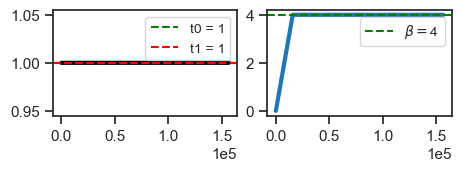

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
print(f"{vars(tr.model.cfg)}\n\n\n{vars(tr.cfg)}")

{'_type': 'gaussian', 'latent_act': 'logistic', 't_train': 16, 'kl_beta': 4.0, 'n_latents': 512, 'enc_type': 'ngd',
'dec_type': 'lin', 'recon_mode': 'mse', 'dataset': 'Kyoto16-bw', 'dataset_name': 'Kyoto16-bw', 'feeder': 
'stationary', 'feeder_cfg': {}, 'input_sz': (1, 16, 16), 'shape': (-1, 1, 16, 16), 'init_dist': 'normal', 
'init_scale': 0.0001, 'clamp_vals': {'u': (7.0, 2.0), 'du': (7.0, 3.0), 'dec': 3.45}, 'stochastic': True, 
'fit_dec_var': False, 'fit_prior': True, 'seed': 0, 'track_stats': True, 'base_dir': 
'/home/hadi/Projects/PoissonVAE', 'data_dir': '/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/PoissonVAE/runs/gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|lin>', 'mods_dir': 
'/home/hadi/Projects/PoissonVAE/models/gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|lin>', 'results_dir': 
'/home/hadi/Projects/PoissonVAE/results'}


{'lr': 0.001, 'epochs': 800, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 796.0, 'eta_min': 1e-05}, 'ema_rate': None, 'grad_clip': 
200, 'chkpt_freq': 50, 'eval_freq': 20, 'log_freq': 10, 'method': 'mc', 'kl_beta_min': 0.0001, 'kl_const_portion': 
0.001, 'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.0, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 
'temp_stop': 1.0}

In [7]:
print(tr.model.cfg.clamp_vals)

{'u': (7.0, 2.0), 'du': (7.0, 3.0), 'dec': 3.45}

### Fit model

In [8]:
tr.train('phase9:gaus+logistic+lin')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 800, avg loss: 6.014: 100%|█████████| 800/800 [3:16:17<00:00, 14.72s/it]


**Task:** reproduce this while gradually updating the code

**Conclusion:** 

In [3]:
a = 'gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|lin>'
b = 'b200-ep800-lr(0.001)_gr(200)_phase9:gaus+logistic+lin_(2025_05_28,21:55)'
tr, meta = load_model_main(a, b, device=device)
meta['checkpoint']

800

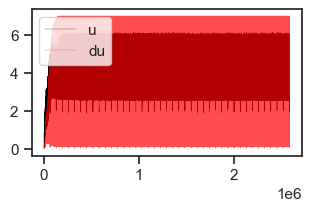

In [10]:
u_max = np.array(tr.model.stats['u_max'])
du_max = np.array(tr.model.stats['du_max'])

fig, ax = create_figure()
ax.plot(u_max, color='k', label='u', lw=0.2)
ax.plot(du_max, color='r', label='du', alpha=0.7, lw=0.2)
ax.legend()
plt.show()

In [11]:
max(tr.model.stats['du_max']), np.quantile(tr.model.stats['du_max'], 0.999)

(7.0, 7.0)

In [12]:
max(tr.model.stats['u_max']), np.quantile(tr.model.stats['u_max'], 0.999)

(6.194482803344727, 6.0229165134429925)

100%|█████████████████████████████████| 10/10 [00:20<00:00,  2.01s/it]


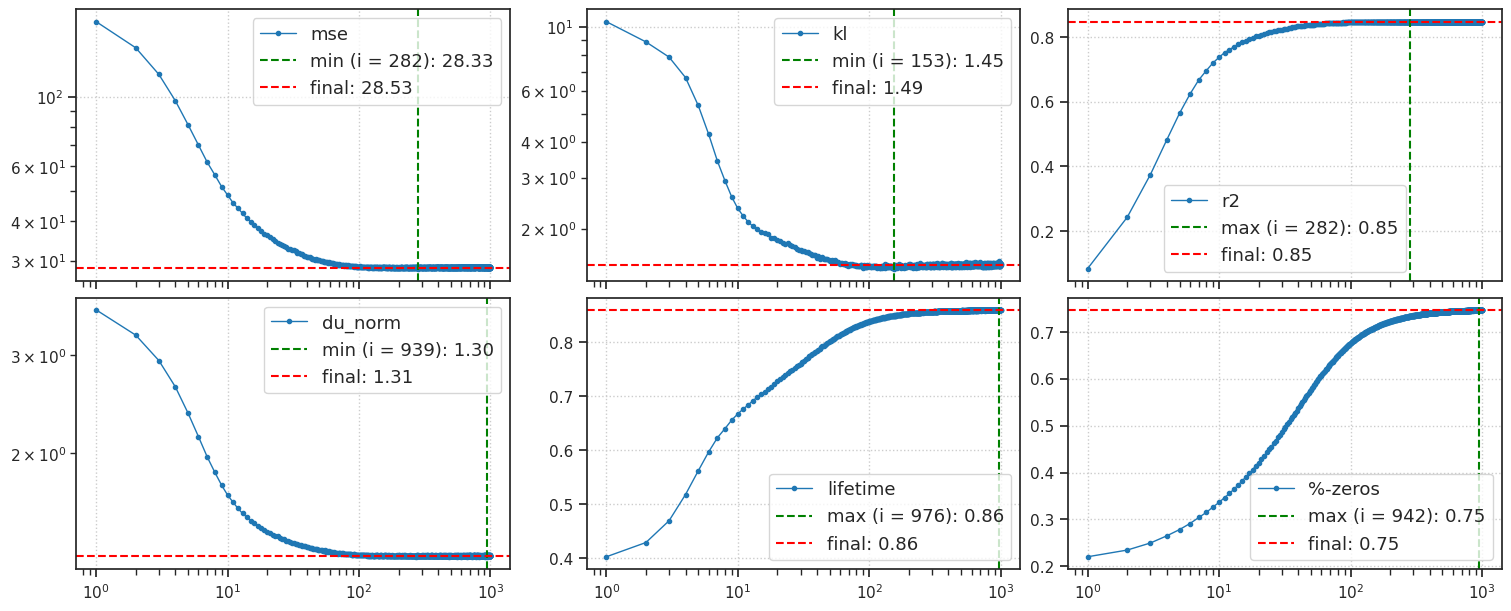

CPU times: user 27.1 s, sys: 728 ms, total: 27.8 s
Wall time: 27.8 s


In [17]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=True,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

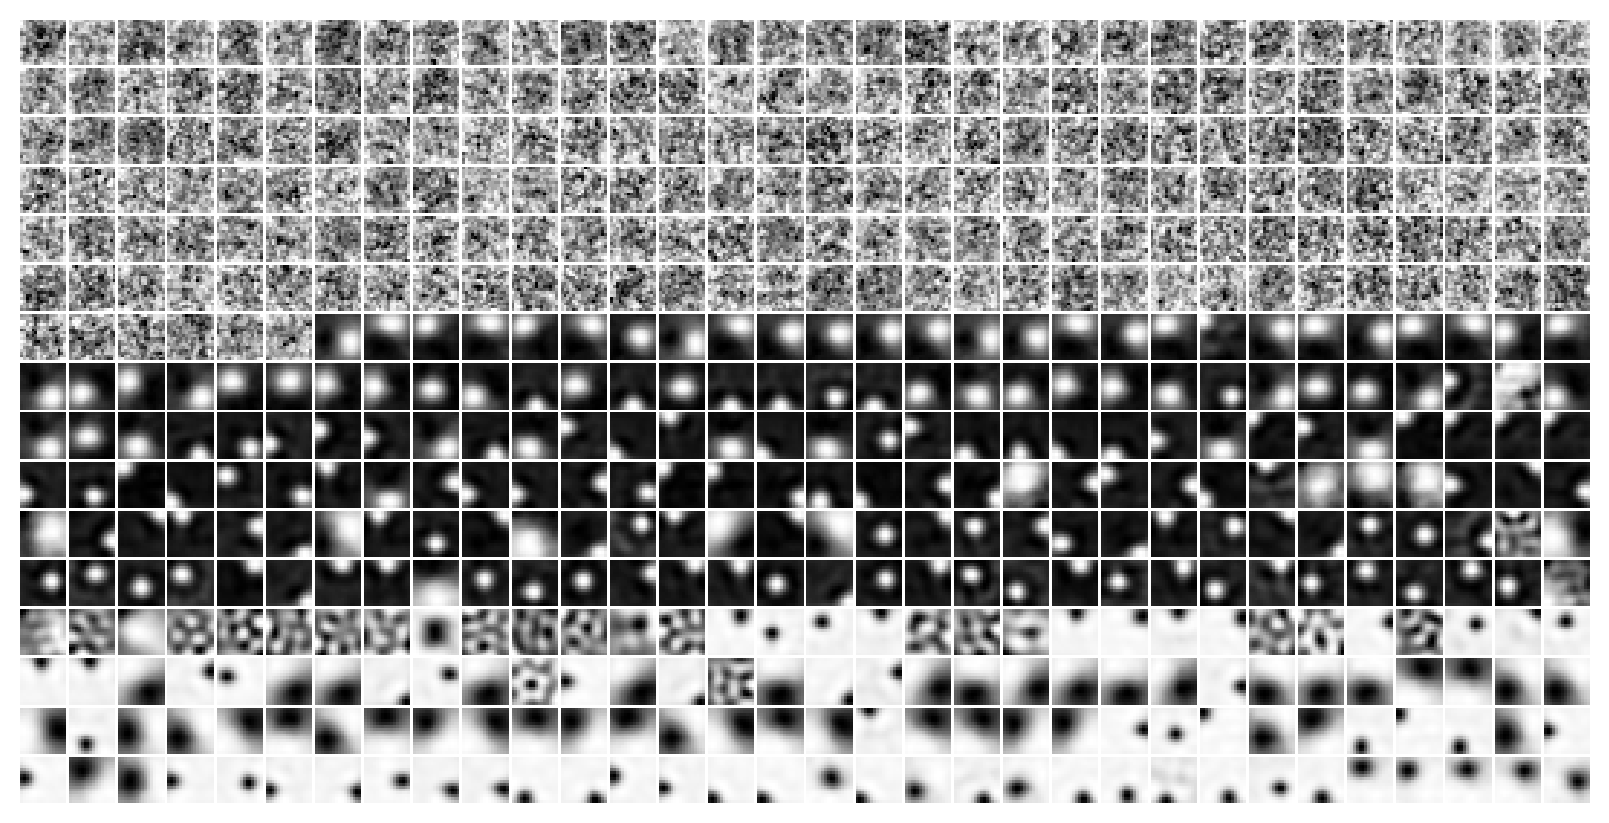

In [13]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), dpi=200, pad=1);

In [3]:
a = 'gaussian+logistic_Kyoto16-bw_t-16_b-4_k-512_<ngd|lin>'
b = 'b200-ep800-lr(0.001)_gr(200)_phase9:gaus+logistic+lin_(2025_05_28,21:55)'
tr, meta = load_model_main(a, b, device=device)
meta['checkpoint']

800

In [10]:
results = tr.xtract_ftr(
    t_total=100, save_freq=100, n_data_batches=10,
    return_recon=True, verbose=True, only_pos_r2=False,
)
list(results)

100%|█████████████████████████████████| 10/10 [00:03<00:00,  2.89it/s]


['r2',
 'mse',
 'du_norm_0',
 'du_norm_1',
 'samples',
 'state_0',
 'state_1',
 'recon',
 'times']

In [11]:
results['r2'].shape

(100,)

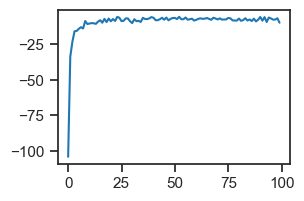

In [12]:
plot(results['r2'])
plt.show()

In [5]:
x = next(iter(tr.dl_vld))[0]
x = x.flatten(start_dim=1)
x.shape

torch.Size([200, 256])

In [6]:
recons = {}
for mode in ['prob', 'mse', 'exact', 'r2']:
    recons[mode] = tr.model.layer.loss_recon(x, mode=mode)

In [7]:
recons

{'prob': tensor([236.6783, 236.2905, 237.7992, 235.4610, 235.5799, 235.7795, 235.8952,
         235.8530, 235.6398, 235.6202, 235.9300, 235.6465, 236.5734, 237.5019,
         236.7519, 235.6751, 236.8187, 236.0257, 236.0469, 236.0350, 239.1186,
         236.3915, 237.3776, 236.4357, 236.8983, 237.5939, 236.0420, 237.7124,
         235.8446, 238.1609, 239.8560, 238.6200, 236.7257, 238.0608, 241.0871,
         236.0018, 235.8383, 235.4381, 237.0403, 238.2751, 237.3226, 237.6045,
         238.1951, 238.6528, 235.5467, 237.1344, 237.2207, 236.3274, 236.3522,
         236.4955, 236.7299, 236.3699, 236.9488, 238.2645, 237.5143, 237.0267,
         238.4932, 238.0488, 236.2739, 235.9322, 237.6414, 236.4635, 235.9622,
         238.5858, 236.5074, 236.1233, 236.1545, 235.5725, 235.8770, 237.0367,
         236.2053, 236.4285, 235.8786, 236.4484, 236.4467, 235.7178, 236.7467,
         237.0002, 236.3096, 238.0395, 237.6018, 237.4716, 236.9843, 236.5035,
         235.9551, 236.3602, 236.7237, 240.2

array([-0.01,  0.01,  0.03,  0.05,  0.07,  0.09,  0.11,  0.13,  0.15,
        0.17,  0.19,  0.21,  0.23,  0.25,  0.27,  0.29,  0.31,  0.33,
        0.35,  0.37,  0.39,  0.41,  0.43,  0.45,  0.47,  0.49,  0.51,
        0.53,  0.55,  0.57,  0.59,  0.61,  0.63,  0.65,  0.67,  0.69,
        0.71,  0.73,  0.75,  0.77,  0.79,  0.81,  0.83,  0.85,  0.87,
        0.89,  0.91,  0.93,  0.95,  0.97,  0.99,  1.01])

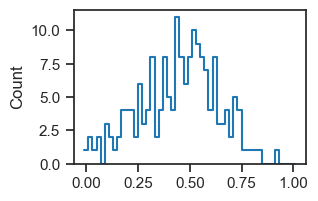

In [19]:
bins = np.linspace(0, 1 + 0.02, 52) - 0.01
histplot(recons['r2'], bins=bins)
plt.show()

In [22]:
r2 = tonp(recons['r2']).copy()
r2 = r2[r2 >= 0]
r2.mean()

0.451468

In [38]:
r2 = recons['r2']
r2 = r2[r2 >= 0]
torch.mean(r2, dim=0)

tensor(0.4515, device='cuda:0')

In [23]:
bias = tonp(tr.model.layer.log_bias.exp().squeeze())

u0 = tonp(tr.model.layer.u_init[0])
phi_u0 = tonp(tr.model.layer.apply_activation(tr.to(u0)))

u0 = u0.squeeze()
phi_u0 = phi_u0.squeeze()

u0.shape, phi_u0.shape

((512,), (512,))

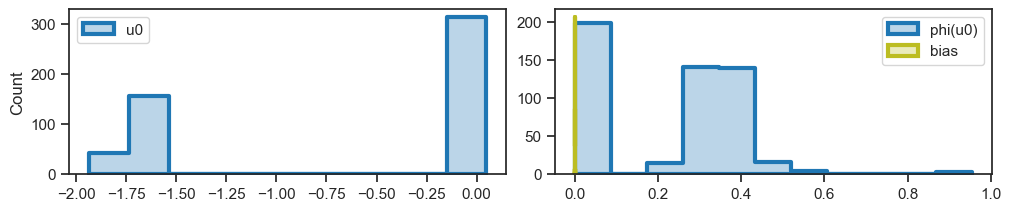

In [24]:
fig, axes = create_figure(1, 2, (10, 2))
kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[0])
sns.histplot(u0, color='C0', element='step', label='u0', **kws)

kws = dict(fill=True, lw=3, alpha=0.3, ax=axes[1])
sns.histplot(phi_u0, color='C0', element='step', label='phi(u0)', **kws)
sns.histplot(bias, color='C8', element='step', label='bias', **kws)

axes[1].set(ylabel='')
add_legend(axes)

plt.show()

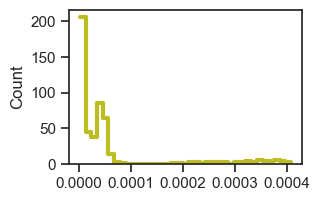

In [26]:
histplot(bias, color='C8', lw=3)
plt.show()

In [22]:
(bias > 0).mean()

1.0

In [23]:
bias[dead]

array([], dtype=float32)

In [30]:
self = tr.model.layer

In [31]:
phi = self.dec.weight
phi.shape

torch.Size([256, 512])

In [32]:
phi_correct = self.dec.get_weight()
phi_correct.shape

torch.Size([256, 512])

In [33]:
phi_correct - phi

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0',
       grad_fn=<SubBackward0>)

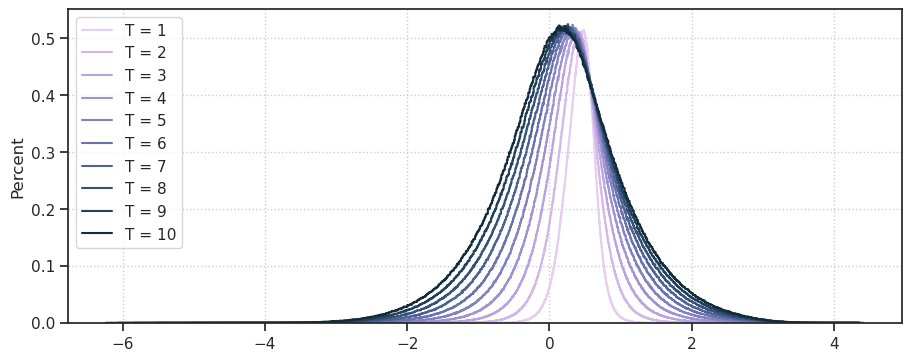

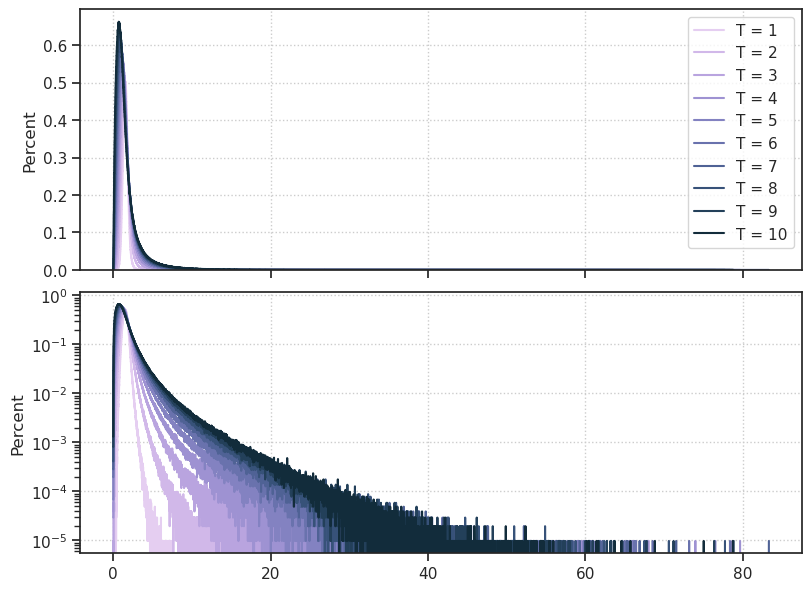

In [25]:
mult = 1

results = tr.xtract_ftr(
    t_total=tr.model.cfg.t_train * mult,
    save_freq=mult,
    n_data_batches=10,
    data_batch_sz=2000,
    verbose=False,
)


fig, ax = create_figure(1, 1, (9, 3.5))
pal = get_cubehelix_palette(len(results['times']), start=2.5)

for i, t in enumerate(results['times']):
    sns.histplot(
        results['state_0'][:, i].ravel(),
        stat='percent',
        element='step',
        fill=False,
        color=pal[i],
        label=f"T = {t}",
        ax=ax,
    )
ax.legend(loc='upper left')
ax.grid()
plt.show()


fig, axes = create_figure(2, 1, (8, 5.8), sharex='col')
for i, t in enumerate(results['times']):
    for ax in axes.flat:
        sns.histplot(
            np.exp(results['state_0'][:, i].ravel()),
            stat='percent',
            element='step',
            fill=False,
            color=pal[i],
            label=f"T = {t}",
            ax=ax,
        )
axes[0].legend()
axes[1].set(yscale='log')
add_grid(axes)
plt.show()

In [26]:
pal

[[0.8975507056831679, 0.8094812603307622, 0.9465577040964425],
 [0.8178323483750889, 0.7228373334284097, 0.9156857084467959],
 [0.7243842279061081, 0.6447757533596252, 0.8762257510361532],
 [0.621433610824204, 0.5738491579616475, 0.8244120665462615],
 [0.5137602016853071, 0.5080741960907603, 0.7578471038208457],
 [0.41165859076399486, 0.44819771588937396, 0.6800995692970601],
 [0.3090934491249027, 0.3854178083786437, 0.5835384610223103],
 [0.2159918198929715, 0.32026582325789205, 0.4738907509899629],
 [0.13614552585465997, 0.2501791993868458, 0.35455980691569594],
 [0.07235872150128392, 0.17287618251766537, 0.23013648857700542]]

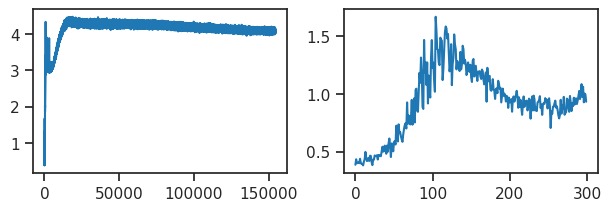

In [27]:
grad = np.array(list(tr.stats['grad'].values()))

fig, axes = create_figure(1, 2)
axes[0].plot(np.log(grad))
axes[1].plot(np.log(grad)[:300])
plt.show()

In [28]:
(grad > 100).sum()

0

100%|█████████████████████████████████| 50/50 [01:40<00:00,  2.01s/it]


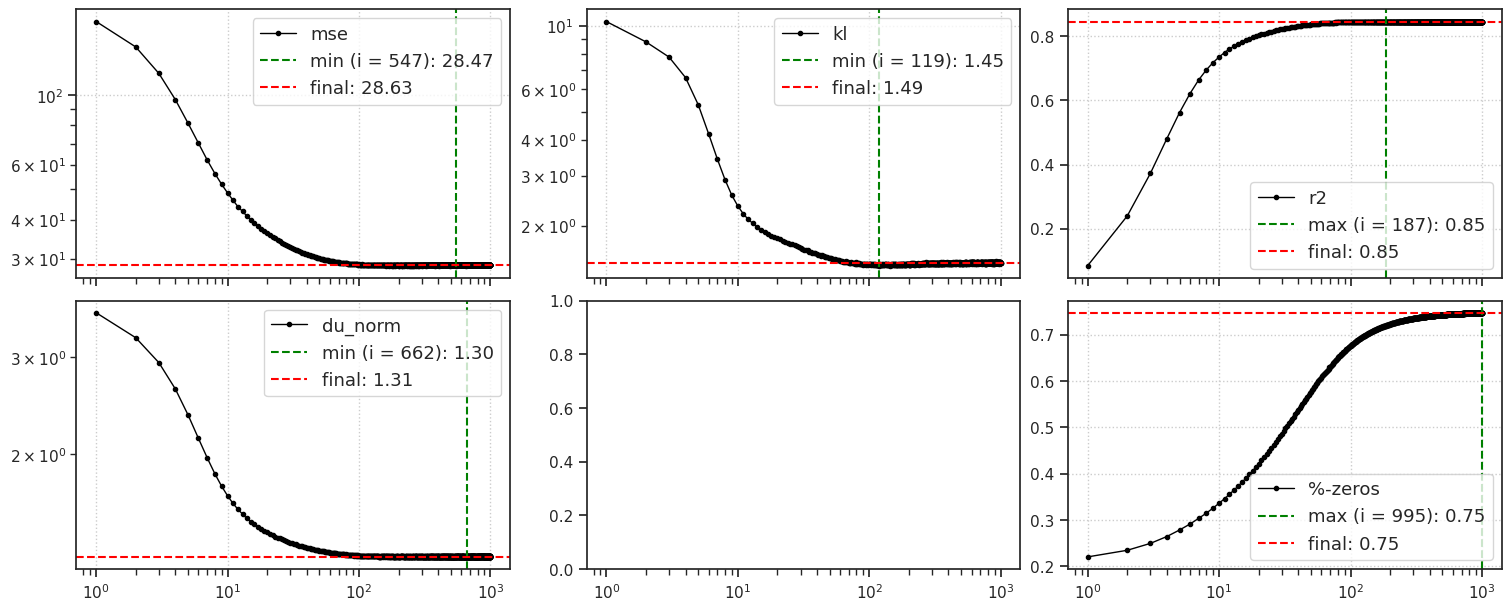

CPU times: user 2min 7s, sys: 3.6 s, total: 2min 11s
Wall time: 2min 11s


In [30]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=50,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')